Import Libraries

In [7]:
import pandas as pd
import os

In [8]:
file_path = r'D:\Deloitte\case study\case study 2 week 2\E-commerce-Order-Fulfillment-Delivery-Analytics\SAP-DataSet.xlsx'

In [9]:
pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:

xls = pd.ExcelFile(file_path)

print("Available Sheets:")
print(xls.sheet_names)

Available Sheets:
['KNA1', 'LFA1', 'VBAK', 'VBAP', 'LIKP', 'LIPS', 'VTTK', 'VTTP']


In [11]:
vbak = pd.read_excel(xls, sheet_name='VBAK')

vbap = pd.read_excel(xls, sheet_name='VBAP')

likp = pd.read_excel(xls, sheet_name='LIKP')

lips = pd.read_excel(xls, sheet_name='LIPS')

kna1 = pd.read_excel(xls, sheet_name='KNA1')

lfa1 = pd.read_excel(xls, sheet_name='LFA1')

vttk = pd.read_excel(xls, sheet_name='VTTK')

vttp = pd.read_excel(xls, sheet_name='VTTP')

Initial Data Inspection

In [12]:
#check dimensions
print("VBAK Shape:", vbak.shape)
print("VBAP Shape:", vbap.shape)
print("LIKP Shape:", likp.shape)
print("LIPS Shape:", lips.shape)
print("KNA1 Shape:", kna1.shape)
print("LFA1 Shape:", lfa1.shape)
print("VTTK Shape:", vttk.shape)
print("VTTP Shape:", vttp.shape)

VBAK Shape: (22, 8)
VBAP Shape: (23, 7)
LIKP Shape: (20, 10)
LIPS Shape: (21, 10)
KNA1 Shape: (30, 15)
LFA1 Shape: (30, 12)
VTTK Shape: (20, 10)
VTTP Shape: (21, 10)


In [13]:
vbak.head()


,Sales Document,Order Date,Customer ID,Order Type,Sales Organization,Distribution Channel,Division,Order Status
0,1000001,2025-02-01,CUST001,OR,1000,10,1,Open
1,1000002,2025-02-02,CUST002,OR,1000,20,1,Delivered
2,1000003,2025-02-05,CUST003,OR,1000,10,1,Open
3,1000004,2025-02-06,CUST004,OR,1000,10,1,Closed
4,1000005,2025-02-07,CUST005,OR,1000,20,1,Open


In [14]:
vbap.head()
likp.head()
lips.head()
kna1.head()
lfa1.head()
vttk.head()
vttp.head()

,Shipment Number,Item Number,Material Number,Shipped Quantity,Item Status,Delivery Number,Customer ID,Sales Document,Sales Item,Shipment Date
0,2001001,10,MAT001,100,Delivered,1001001,CUST001,1000001,10,2025-02-10
1,2001001,20,MAT002,200,Delivered,1001001,CUST001,1000001,20,2025-02-10
2,2001002,10,MAT003,150,Delivered,1001002,CUST002,1000002,10,2025-02-11
3,2001003,10,MAT001,300,Delivered,1001003,CUST003,1000003,10,2025-02-12
4,2001004,10,MAT004,500,Delivered,1001004,CUST004,1000004,10,2025-02-13


In [15]:
vbak.info()
vbap.info()
likp.info()
lips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Sales Document        22 non-null     int64         
 1   Order Date            22 non-null     datetime64[ns]
 2   Customer ID           22 non-null     object        
 3   Order Type            22 non-null     object        
 4   Sales Organization    22 non-null     int64         
 5   Distribution Channel  22 non-null     int64         
 6   Division              22 non-null     int64         
 7   Order Status          22 non-null     object        
dtypes: datetime64[ns](1), int64(4), object(3)
memory usage: 1.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Sales Document   23 non-null     int

Standardize Date Columns

In [17]:
#Orders Date
vbak['ERDAT'] = pd.to_datetime(vbak['ERDAT'], errors='coerce')
# Shipment Date
likp['WADAT'] = pd.to_datetime(likp['WADAT'], errors='coerce')
# Delivery Date
lips['LFDAT'] = pd.to_datetime(lips['LFDAT'], errors='coerce')

KeyError: 'ERDAT'

In [18]:

dataframes = {
    "VBAK": vbak,
    "VBAP": vbap,
    "LIKP": likp,
    "LIPS": lips,
    "KNA1": kna1,
    "LFA1": lfa1,
    "VTTK": vttk,
    "VTTP": vttp
}

for name, df in dataframes.items():
    print(f"\n{name} Columns:")
    print(df.columns.tolist())


VBAK Columns:
['Sales Document', 'Order Date', 'Customer ID', 'Order Type', 'Sales Organization', 'Distribution Channel', 'Division', 'Order Status']

VBAP Columns:
['Sales Document', 'Item Number', 'Material Number', 'Quantity', 'Net Price', 'Item Status', 'Delivery Date']

LIKP Columns:
['Delivery Number', 'Delivery Date', 'Sales Document', 'Shipping Point', 'Shipping Type', 'Delivery Status', 'Shipping Status', 'Route', 'Delivery Priority', 'Customer ID']

LIPS Columns:
['Delivery Number', 'Item Number', 'Material Number', 'Delivered Quantity', 'Net Price', 'Delivery Status', 'Customer ID', 'Sales Document', 'Sales Item', 'Delivery Date']

KNA1 Columns:
['Customer ID', 'Customer Name', 'Country', 'Region', 'City', 'Postal Code', 'Street Address', 'Phone Number', 'Email Address', 'Language', 'Tax Number', 'Customer Group', 'Sales Organization', 'Distribution Channel', 'Division']

LFA1 Columns:
['Vendor Number', 'Vendor Name', 'Country', 'Region', 'City', 'Postal Code', 'Street Addr

DATA PROFILING & VALIDATION

Missing Value Analysis

In [19]:
vbak[['Sales Document', 'Order Date', 'Customer ID']].isnull().sum()



Sales Document    0
Order Date        0
Customer ID       0
dtype: int64

In [20]:
vbap[['Sales Document', 'Item Number', 'Material Number']].isnull().sum()

Sales Document     0
Item Number        0
Material Number    0
dtype: int64

In [21]:
likp[['Delivery Number', 'Sales Document', 'Customer ID']].isnull().sum()


Delivery Number    0
Sales Document     0
Customer ID        0
dtype: int64

In [22]:
lips[['Delivery Number', 'Material Number', 'Sales Document']].isnull().sum()

Delivery Number    0
Material Number    0
Sales Document     0
dtype: int64

Duplicate Detection

In [23]:
vbak['Sales Document'].duplicated().sum()

np.int64(0)

In [24]:
vbap.duplicated(subset=['Sales Document','Item Number']).sum()

np.int64(0)

In [25]:
likp['Delivery Number'].duplicated().sum()

np.int64(0)

In [ ]:
lips.duplicated(subset=['Delivery Number','Item Number']).sum()

np.int64(0)

Referential Integrity Checks

In [26]:
#Items Without Orders
invalid_items = vbap[~vbap['Sales Document'].isin(vbak['Sales Document'])]

invalid_items

,Sales Document,Item Number,Material Number,Quantity,Net Price,Item Status,Delivery Date


In [27]:
#Deliveries Without Orders
invalid_deliveries = likp[~likp['Sales Document'].isin(vbak['Sales Document'])]

invalid_deliveries

,Delivery Number,Delivery Date,Sales Document,Shipping Point,Shipping Type,Delivery Status,Shipping Status,Route,Delivery Priority,Customer ID


In [28]:
#Delivery Items Without Deliveries
invalid_delivery_items = lips[~lips['Delivery Number'].isin(likp['Delivery Number'])]

invalid_delivery_items

,Delivery Number,Item Number,Material Number,Delivered Quantity,Net Price,Delivery Status,Customer ID,Sales Document,Sales Item,Delivery Date


In [29]:
#Shipments Without Deliveries
invalid_shipments = vttk[~vttk['Delivery Number'].isin(likp['Delivery Number'])]

invalid_shipments

,Shipment Number,Shipment Date,Sales Document,Delivery Number,Shipping Point,Carrier,Shipment Status,Route,Shipping Type,Customer ID


Date Validation

In [30]:
vbak['Order Date'] = pd.to_datetime(vbak['Order Date'], errors='coerce')
likp['Delivery Date'] = pd.to_datetime(likp['Delivery Date'], errors='coerce')
lips['Delivery Date'] = pd.to_datetime(lips['Delivery Date'], errors='coerce')
vttk['Shipment Date'] = pd.to_datetime(vttk['Shipment Date'], errors='coerce')
vttp['Shipment Date'] = pd.to_datetime(vttp['Shipment Date'], errors='coerce')

Detect Invalid Dates

In [31]:
vbak[vbak['Order Date'].isnull()]

,Sales Document,Order Date,Customer ID,Order Type,Sales Organization,Distribution Channel,Division,Order Status


Logical Date Consistency

In [32]:
#Shipment Before Order?
merged_dates = pd.merge(
    vbak,
    vttk,
    on='Sales Document',
    how='inner'
)

invalid_flow = merged_dates[
    merged_dates['Shipment Date'] < merged_dates['Order Date']
]

invalid_flow

,Sales Document,Order Date,Customer ID_x,Order Type,Sales Organization,Distribution Channel,Division,Order Status,Shipment Number,Shipment Date,Delivery Number,Shipping Point,Carrier,Shipment Status,Route,Shipping Type,Customer ID_y


In [33]:
#Delivery Before Shipment?
merged_delivery = pd.merge(
    vttk,
    lips,
    on='Delivery Number',
    how='inner'
)

invalid_delivery = merged_delivery[
    merged_delivery['Delivery Date'] < merged_delivery['Shipment Date']
]

invalid_delivery

,Shipment Number,Shipment Date,Sales Document_x,Delivery Number,Shipping Point,Carrier,Shipment Status,Route,Shipping Type,Customer ID_x,Item Number,Material Number,Delivered Quantity,Net Price,Delivery Status,Customer ID_y,Sales Document_y,Sales Item,Delivery Date


Numeric Validation

In [ ]:
#Negative Quantities?
vbap[vbap['Quantity'] < 0]


,Sales Document,Item Number,Material Number,Quantity,Net Price,Item Status,Delivery Date


In [36]:
#Weird Prices?
vbap[vbap['Net Price'] <= 0]

,Sales Document,Item Number,Material Number,Quantity,Net Price,Item Status,Delivery Date


In [37]:
#Delivered Quantity Issues?
lips[lips['Delivered Quantity'] < 0]

,Delivery Number,Item Number,Material Number,Delivered Quantity,Net Price,Delivery Status,Customer ID,Sales Document,Sales Item,Delivery Date


Transform Customers (KNA1 → DW_Customers)

In [38]:
dw_customers = kna1.copy()

dw_customers = dw_customers.rename(columns={
    'Customer ID': 'customer_id',
    'Customer Name': 'customer_name',
    'Country': 'country',
    'Region': 'region',
    'City': 'city',
    'Postal Code': 'postal_code',
    'Street Address': 'street_address',
    'Phone Number': 'phone_number',
    'Email Address': 'email',
    'Language': 'language',
    'Tax Number': 'tax_number',
    'Customer Group': 'customer_group',
    'Sales Organization': 'sales_organization',
    'Distribution Channel': 'distribution_channel',
    'Division': 'division'
})

dw_customers = dw_customers.drop_duplicates(subset=['customer_id'])
dw_customers = dw_customers.reset_index(drop=True)

dw_customers.head()

,customer_id,customer_name,country,region,city,postal_code,street_address,phone_number,email,language,tax_number,customer_group,sales_organization,distribution_channel,division
0,CUST001,Customer A,US,NY,New York,10001,123 Park Avenue,1-212-5551234,customerA@email.com,EN,1234567890,1,1000,10,1
1,CUST002,Customer B,DE,BW,Stuttgart,70173,Hauptstrasse 10,49-711-5552345,customerB@email.de,DE,2345678901,2,1000,20,2
2,CUST003,Customer C,UK,ENG,London,EC1A 1BB,5 Oxford Street,44-20-5559876,customerC@email.co.uk,EN,3456789012,1,2000,10,3
3,CUST004,Customer D,FR,IDF,Paris,75001,10 Rue de Rivoli,33-1-5556543,customerD@email.fr,FR,4567890123,3,2000,30,1
4,CUST005,Customer E,IN,DL,New Delhi,110001,20 MG Road,91-11-5554321,customerE@email.in,HI,5678901234,4,3000,40,2


Transform Orders (VBAK → DW_Orders)

In [39]:
dw_orders = vbak.copy()

dw_orders = dw_orders.rename(columns={
    'Sales Document': 'order_id',
    'Order Date': 'order_date',
    'Customer ID': 'customer_id',
    'Order Type': 'order_type',
    'Sales Organization': 'sales_organization',
    'Distribution Channel': 'distribution_channel',
    'Division': 'division',
    'Order Status': 'order_status'
})

dw_orders = dw_orders.drop_duplicates(subset=['order_id'])
dw_orders = dw_orders.reset_index(drop=True)

dw_orders.head()

,order_id,order_date,customer_id,order_type,sales_organization,distribution_channel,division,order_status
0,1000001,2025-02-01,CUST001,OR,1000,10,1,Open
1,1000002,2025-02-02,CUST002,OR,1000,20,1,Delivered
2,1000003,2025-02-05,CUST003,OR,1000,10,1,Open
3,1000004,2025-02-06,CUST004,OR,1000,10,1,Closed
4,1000005,2025-02-07,CUST005,OR,1000,20,1,Open


Transform Order Items (VBAP → DW_Order_Items)

In [40]:
dw_order_items = vbap.copy()

dw_order_items = dw_order_items.rename(columns={
    'Sales Document': 'order_id',
    'Item Number': 'item_number',
    'Material Number': 'material_number',
    'Quantity': 'quantity',
    'Net Price': 'net_price',
    'Item Status': 'item_status',
    'Delivery Date': 'requested_delivery_date'
})

dw_order_items = dw_order_items.drop_duplicates(
    subset=['order_id', 'item_number']
)

dw_order_items = dw_order_items.reset_index(drop=True)

dw_order_items.head()

,order_id,item_number,material_number,quantity,net_price,item_status,requested_delivery_date
0,1000001,10,MAT001,100,50,Open,2025-02-08
1,1000001,20,MAT002,200,30,Open,2025-02-08
2,1000002,10,MAT003,150,40,Delivered,2025-02-09
3,1000003,10,MAT001,300,50,Open,2025-02-10
4,1000004,10,MAT004,500,25,Closed,2025-02-12


Transform Carriers (LFA1 → DW_Carriers)

In [41]:
dw_carriers = lfa1.copy()

dw_carriers = dw_carriers.rename(columns={
    'Vendor Number': 'carrier_id',
    'Vendor Name': 'carrier_name',
    'Country': 'country',
    'Region': 'region',
    'City': 'city',
    'Postal Code': 'postal_code',
    'Street Address': 'street_address',
    'Phone Number': 'phone_number',
    'Email Address': 'email',
    'Language': 'language',
    'Tax Number': 'tax_number',
    'Payment Terms': 'payment_terms'
})

dw_carriers = dw_carriers.drop_duplicates(subset=['carrier_id'])
dw_carriers = dw_carriers.reset_index(drop=True)

dw_carriers.head()

,carrier_id,carrier_name,country,region,city,postal_code,street_address,phone_number,email,language,tax_number,payment_terms
0,1000001,Vendor A,US,NY,New York,10001,123 Park Avenue,-5551445,vendorA@email.com,EN,1234567890,30 Days
1,1000002,Vendor B,DE,BW,Stuttgart,70173,Hauptstrasse 10,-5553007,vendorB@email.de,DE,2345678901,60 Days
2,1000003,Vendor C,UK,ENG,London,EC1A 1BB,5 Oxford Street,-5559852,vendorC@email.co.uk,EN,3456789012,45 Days
3,1000004,Vendor D,FR,IDF,Paris,75001,10 Rue de Rivoli,-5556511,vendorD@email.fr,FR,4567890123,30 Days
4,1000005,Vendor E,IN,DL,New Delhi,110001,20 MG Road,-5554241,vendorE@email.in,HI,5678901234,90 Days


Transform Shipments (LIKP + VTTK)

In [42]:
# Rename LIKP
likp_clean = likp.rename(columns={
    'Delivery Number': 'delivery_number',
    'Delivery Date': 'delivery_date',
    'Sales Document': 'order_id',
    'Shipping Point': 'shipping_point',
    'Shipping Type': 'shipping_type',
    'Delivery Status': 'delivery_status',
    'Shipping Status': 'shipping_status',
    'Route': 'route',
    'Delivery Priority': 'delivery_priority',
    'Customer ID': 'customer_id'
})

# Rename VTTK
vttk_clean = vttk.rename(columns={
    'Shipment Number': 'shipment_number',
    'Shipment Date': 'shipment_date',
    'Sales Document': 'order_id',
    'Delivery Number': 'delivery_number',
    'Shipping Point': 'shipping_point',
    'Carrier': 'carrier_id',
    'Shipment Status': 'shipment_status',
    'Route': 'route',
    'Shipping Type': 'shipping_type',
    'Customer ID': 'customer_id'
})

# Merge Shipment Header + Delivery Header
dw_shipments = pd.merge(
    vttk_clean,
    likp_clean,
    on=['delivery_number', 'order_id'],
    how='left'
)

dw_shipments = dw_shipments.drop_duplicates(subset=['shipment_number'])
dw_shipments = dw_shipments.reset_index(drop=True)

dw_shipments.head()

,shipment_number,shipment_date,order_id,delivery_number,shipping_point_x,carrier_id,shipment_status,route_x,shipping_type_x,customer_id_x,delivery_date,shipping_point_y,shipping_type_y,delivery_status,shipping_status,route_y,delivery_priority,customer_id_y
0,2001001,2025-02-10,1000001,1001001,SP001,Carrier1,In Transit,1,Standard,CUST001,2025-02-10,SP001,Standard,Open,Not Shipped,1,High,CUST001
1,2001002,2025-02-11,1000002,1001002,SP002,Carrier2,Delivered,2,Express,CUST002,2025-02-11,SP002,Express,Delivered,Shipped,2,Medium,CUST002
2,2001003,2025-02-12,1000003,1001003,SP001,Carrier1,In Transit,3,Standard,CUST003,2025-02-12,SP001,Standard,Open,Not Shipped,3,Low,CUST003
3,2001004,2025-02-13,1000004,1001004,SP003,Carrier3,Delivered,4,Express,CUST004,2025-02-13,SP003,Express,Delivered,Shipped,4,High,CUST004
4,2001005,2025-02-14,1000005,1001005,SP001,Carrier1,In Transit,5,Standard,CUST005,2025-02-14,SP001,Standard,Open,Not Shipped,5,Medium,CUST005


In [ ]:
(dw_shipments['customer_id_x'] 
 == dw_shipments['customer_id_y']).all()



np.True_

In [94]:
(dw_shipments['shipping_type_x'] 
 == dw_shipments['shipping_type_y']).all()

np.True_

In [95]:
dw_shipments.rename(columns={
    'customer_id_x': 'customer_id',
    'shipping_type_x': 'shipping_type',
    'shipping_point_x': 'shipping_point',
    'route_x': 'route'
}, inplace=True)

dw_shipments.drop(columns=[
    'customer_id_y',
    'shipping_type_y',
    'shipping_point_y',
    'route_y'
], inplace=True)

In [96]:

dw_shipments.head()

,shipment_number,shipment_date,order_id,delivery_number,shipping_point,carrier_id,shipment_status,route,shipping_type,customer_id,delivery_date,delivery_status,shipping_status,delivery_priority
0,2001001,2025-02-10,1000001,1001001,SP001,Carrier1,In Transit,1,Standard,CUST001,2025-02-10,Open,Not Shipped,High
1,2001002,2025-02-11,1000002,1001002,SP002,Carrier2,Delivered,2,Express,CUST002,2025-02-11,Delivered,Shipped,Medium
2,2001003,2025-02-12,1000003,1001003,SP001,Carrier1,In Transit,3,Standard,CUST003,2025-02-12,Open,Not Shipped,Low
3,2001004,2025-02-13,1000004,1001004,SP003,Carrier3,Delivered,4,Express,CUST004,2025-02-13,Delivered,Shipped,High
4,2001005,2025-02-14,1000005,1001005,SP001,Carrier1,In Transit,5,Standard,CUST005,2025-02-14,Open,Not Shipped,Medium


Transform Shipment Items (LIPS + VTTP)

In [46]:
lips_clean = lips.rename(columns={
    'Delivery Number': 'delivery_number',
    'Item Number': 'item_number',
    'Material Number': 'material_number',
    'Delivered Quantity': 'delivered_quantity',
    'Net Price': 'net_price',
    'Delivery Status': 'delivery_status',
    'Customer ID': 'customer_id',
    'Sales Document': 'order_id',
    'Sales Item': 'sales_item',
    'Delivery Date': 'delivery_date'
})

vttp_clean = vttp.rename(columns={
    'Shipment Number': 'shipment_number',
    'Item Number': 'item_number',
    'Material Number': 'material_number',
    'Shipped Quantity': 'shipped_quantity',
    'Item Status': 'item_status',
    'Delivery Number': 'delivery_number',
    'Customer ID': 'customer_id',
    'Sales Document': 'order_id',
    'Sales Item': 'sales_item',
    'Shipment Date': 'shipment_date'
})

lips_clean = lips.rename(columns={
    'Delivery Number': 'delivery_number',
    'Item Number': 'item_number',
    'Material Number': 'material_number',
    'Delivered Quantity': 'delivered_quantity',
    'Net Price': 'net_price',
    'Delivery Status': 'delivery_status',
    'Customer ID': 'customer_id',
    'Sales Document': 'order_id',
    'Sales Item': 'sales_item',
    'Delivery Date': 'delivery_date'
})

vttp_clean = vttp.rename(columns={
    'Shipment Number': 'shipment_number',
    'Item Number': 'item_number',
    'Material Number': 'material_number',
    'Shipped Quantity': 'shipped_quantity',
    'Item Status': 'item_status',
    'Delivery Number': 'delivery_number',
    'Customer ID': 'customer_id',
    'Sales Document': 'order_id',
    'Sales Item': 'sales_item',
    'Shipment Date': 'shipment_date'
})

dw_shipment_items = pd.merge(
    vttp_clean,
    lips_clean,
    on=['delivery_number', 'order_id', 'material_number'],
    how='left'
)

dw_shipment_items.rename(columns={
    'item_number_x': 'item_number'
}, inplace=True)

dw_shipment_items.drop(columns=['item_number_y'], inplace=True)
dw_shipment_items = dw_shipment_items.drop_duplicates(
    subset=['shipment_number', 'item_number']
)

dw_shipment_items = dw_shipment_items.reset_index(drop=True)

dw_shipment_items.head()

,shipment_number,item_number,material_number,shipped_quantity,item_status,delivery_number,customer_id_x,order_id,sales_item_x,shipment_date,delivered_quantity,net_price,delivery_status,customer_id_y,sales_item_y,delivery_date
0,2001001,10,MAT001,100,Delivered,1001001,CUST001,1000001,10,2025-02-10,100,50,Delivered,CUST001,10,2025-02-10
1,2001001,20,MAT002,200,Delivered,1001001,CUST001,1000001,20,2025-02-10,200,30,Delivered,CUST001,20,2025-02-10
2,2001002,10,MAT003,150,Delivered,1001002,CUST002,1000002,10,2025-02-11,150,40,Delivered,CUST002,10,2025-02-11
3,2001003,10,MAT001,300,Delivered,1001003,CUST003,1000003,10,2025-02-12,300,50,Delivered,CUST003,10,2025-02-12
4,2001004,10,MAT004,500,Delivered,1001004,CUST004,1000004,10,2025-02-13,500,25,Delivered,CUST004,10,2025-02-13


In [86]:
(dw_shipment_items['customer_id_x'] 
 == dw_shipment_items['customer_id_y']).all()

np.True_

In [90]:
dw_shipment_items.rename(columns={
    'customer_id_x': 'customer_id',
    'sales_item_x': 'sales_item'
}, inplace=True)

dw_shipment_items.drop(columns=[
    'customer_id_y',
    'sales_item_y'
], inplace=True)

KeyError: "['customer_id_y', 'sales_item_y'] not found in axis"

In [88]:
print(dw_shipment_items.columns)

Index(['shipment_number', 'item_number', 'material_number', 'shipped_quantity',
       'item_status', 'delivery_number', 'customer_id', 'order_id',
       'sales_item', 'shipment_date', 'delivered_quantity', 'net_price',
       'delivery_status', 'delivery_date'],
      dtype='object')


Exploratory Data Analysis (EDA)

In [ ]:
#High-Level Summary
print("Orders:", len(dw_orders))
print("Order Items:", len(dw_order_items))
print("Shipments:", len(dw_shipments))
print("Shipment Items:", len(dw_shipment_items))
print("Customers:", len(dw_customers))

Orders: 22
Order Items: 23
Shipments: 20
Shipment Items: 21
Customers: 30


In [51]:
#Unique Counts
dw_orders['order_id'].nunique()


22

In [52]:
dw_customers['customer_id'].nunique()


30

In [53]:
dw_shipments['shipment_number'].nunique()

20

In [58]:
#Orders per Customer
orders_per_customer = dw_orders.groupby('customer_id').size()

orders_per_customer.describe()

count    22.0
mean      1.0
std       0.0
min       1.0
25%       1.0
50%       1.0
75%       1.0
max       1.0
dtype: float64

In [59]:
#Items per Order
items_per_order = dw_order_items.groupby('order_id').size()

items_per_order.describe()

count    22.000000
mean      1.045455
std       0.213201
min       1.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       2.000000
dtype: float64

<Axes: title={'center': 'Orders Over Time'}, xlabel='order_date'>

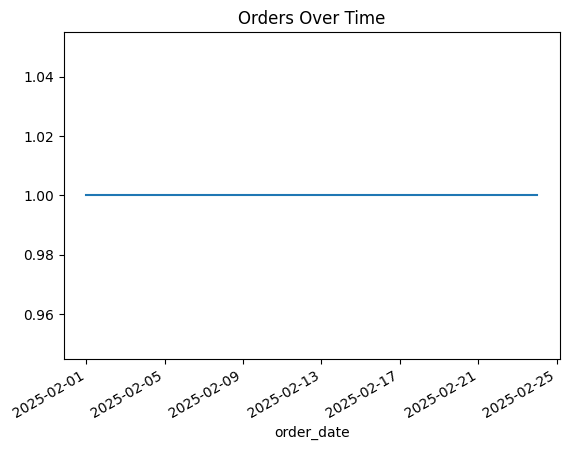

In [97]:
#Time Trend (Orders Over Time)
orders_by_date = dw_orders.groupby('order_date').size()

orders_by_date.plot(title="Orders Over Time")

Shipment Delay Exploration

In [61]:
order_shipment = pd.merge(
    dw_orders,
    dw_shipments,
    on='order_id',
    how='inner'
)

order_shipment['processing_time'] = (
    order_shipment['shipment_date'] - order_shipment['order_date']
).dt.days

order_shipment['processing_time'].describe()

count    20.000000
mean      7.200000
std       0.615587
min       7.000000
25%       7.000000
50%       7.000000
75%       7.000000
max       9.000000
Name: processing_time, dtype: float64

Delivery Time Distribution

In [98]:
print(shipment_delivery.columns.tolist())

['shipment_number', 'shipment_date', 'carrier_id', 'shipment_status', 'shipping_status', 'delivery_priority', 'item_number', 'material_number', 'shipped_quantity', 'item_status', 'delivered_quantity', 'net_price', 'delivery_date']


In [81]:
shipment_delivery.columns = shipment_delivery.columns.str.lower()

shipment_delivery = shipment_delivery.rename(columns={
    'shipment_date_x': 'shipment_date',
    'delivery_date_y': 'delivery_date'
})

In [83]:
cols_to_drop = [col for col in shipment_delivery.columns if col.endswith('_x') or col.endswith('_y')]
shipment_delivery = shipment_delivery.drop(columns=cols_to_drop)

In [75]:
shipment_delivery['shipment_date'] = pd.to_datetime(
    shipment_delivery['shipment_date'],
    errors='coerce'
)

shipment_delivery['delivery_date'] = pd.to_datetime(
    shipment_delivery['delivery_date'],
    errors='coerce'
)

In [100]:
shipment_delivery['delivery_time'] = (
    shipment_delivery['delivery_date'] -
    shipment_delivery['shipment_date']
).dt.days

In [101]:
shipment_delivery['delivery_time'].describe()

count    21.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: delivery_time, dtype: float64

In [85]:
dw_shipments['carrier_id'].value_counts()

carrier_id
Carrier1    8
Carrier2    6
Carrier3    6
Name: count, dtype: int64

LOADING.....PHASE.....

In [103]:
pip install sqlalchemy pyodbc

Defaulting to user installation because normal site-packages is not writeable
  Using cached sqlalchemy-2.0.47-cp313-cp313-win_amd64.whl.metadata (9.8 kB)
  Using cached pyodbc-5.3.0-cp313-cp313-win_amd64.whl.metadata (2.8 kB)
  Using cached greenlet-3.3.2-cp313-cp313-win_amd64.whl.metadata (3.8 kB)
Using cached sqlalchemy-2.0.47-cp313-cp313-win_amd64.whl (2.1 MB)
Using cached pyodbc-5.3.0-cp313-cp313-win_amd64.whl (70 kB)
Using cached greenlet-3.3.2-cp313-cp313-win_amd64.whl (230 kB)

   ------------- -------------------------- 1/3 [greenlet]
   ------------- -------------------------- 1/3 [greenlet]
   ------------- -------------------------- 1/3 [greenlet]
   ------------- -------------------------- 1/3 [greenlet]
   -------------------------- ------------- 2/3 [sqlalchemy]
   -------------------------- ------------- 2/3 [sqlalchemy]
   -------------------------- ------------- 2/3 [sqlalchemy]
   -------------------------- ------------- 2/3 [sqlalchemy]
   --------------------------


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:

from sqlalchemy import create_engine

server = "localhost"
database = "ShopX_DW"   

engine = create_engine(
    f"mssql+pyodbc://@{server}/{database}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
    "&trusted_connection=yes"
)

In [108]:
with engine.connect() as conn:
    print("Connected successfully ✅")

Connected successfully ✅


C:\Users\USER\AppData\Local\Temp\ipykernel_8088\3825709233.py:1: SAWarning: Unrecognized server version info '17.0.1050.2'.  Some SQL Server features may not function properly.
  with engine.connect() as conn:


In [ ]:
dw_customers.to_sql(
    name='DW_Customers',
    con=engine,
    if_exists='replace',   
    index=False
)

print("DW_Customers Loaded ✅")

DW_Customers Loaded ✅


In [110]:
dw_orders.to_sql(
    name='DW_Orders',
    con=engine,
    if_exists='replace',
    index=False
)

print("DW_Orders Loaded ✅")

DW_Orders Loaded ✅


In [111]:
dw_order_items.to_sql(
    name='DW_Order_Items',
    con=engine,
    if_exists='replace',
    index=False
)

print("DW_Order_Items Loaded ✅")

DW_Order_Items Loaded ✅


In [112]:
dw_carriers.to_sql(
    name='DW_Carriers',
    con=engine,
    if_exists='replace',
    index=False
)

print("DW_Carriers Loaded ✅")

DW_Carriers Loaded ✅


In [113]:
dw_shipments.to_sql(
    name='DW_Shipments',
    con=engine,
    if_exists='replace',
    index=False
)

print("DW_Shipments Loaded ✅")

DW_Shipments Loaded ✅


In [114]:
dw_shipment_items.to_sql(
    name='DW_Shipment_Items',
    con=engine,
    if_exists='replace',
    index=False
)

print("DW_Shipment_Items Loaded ✅")

DW_Shipment_Items Loaded ✅
